In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [4]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download(" faresashraf1001/supermarket-sales")

print("Path to dataset files:", path)
df=pd.read_csv(f'{path}/SuperMarket Analysis.csv')


KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.

In [ ]:
df.info()

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['gross margin percentage', 'Tax 5%'])

# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print(df.isnull().sum())


In [ ]:
# Group by date and sum sales & gross income
daily_summary = df.groupby('Date').agg({
    'Sales': 'sum',
    'gross income': 'sum'
}).reset_index()

print(daily_summary.head())


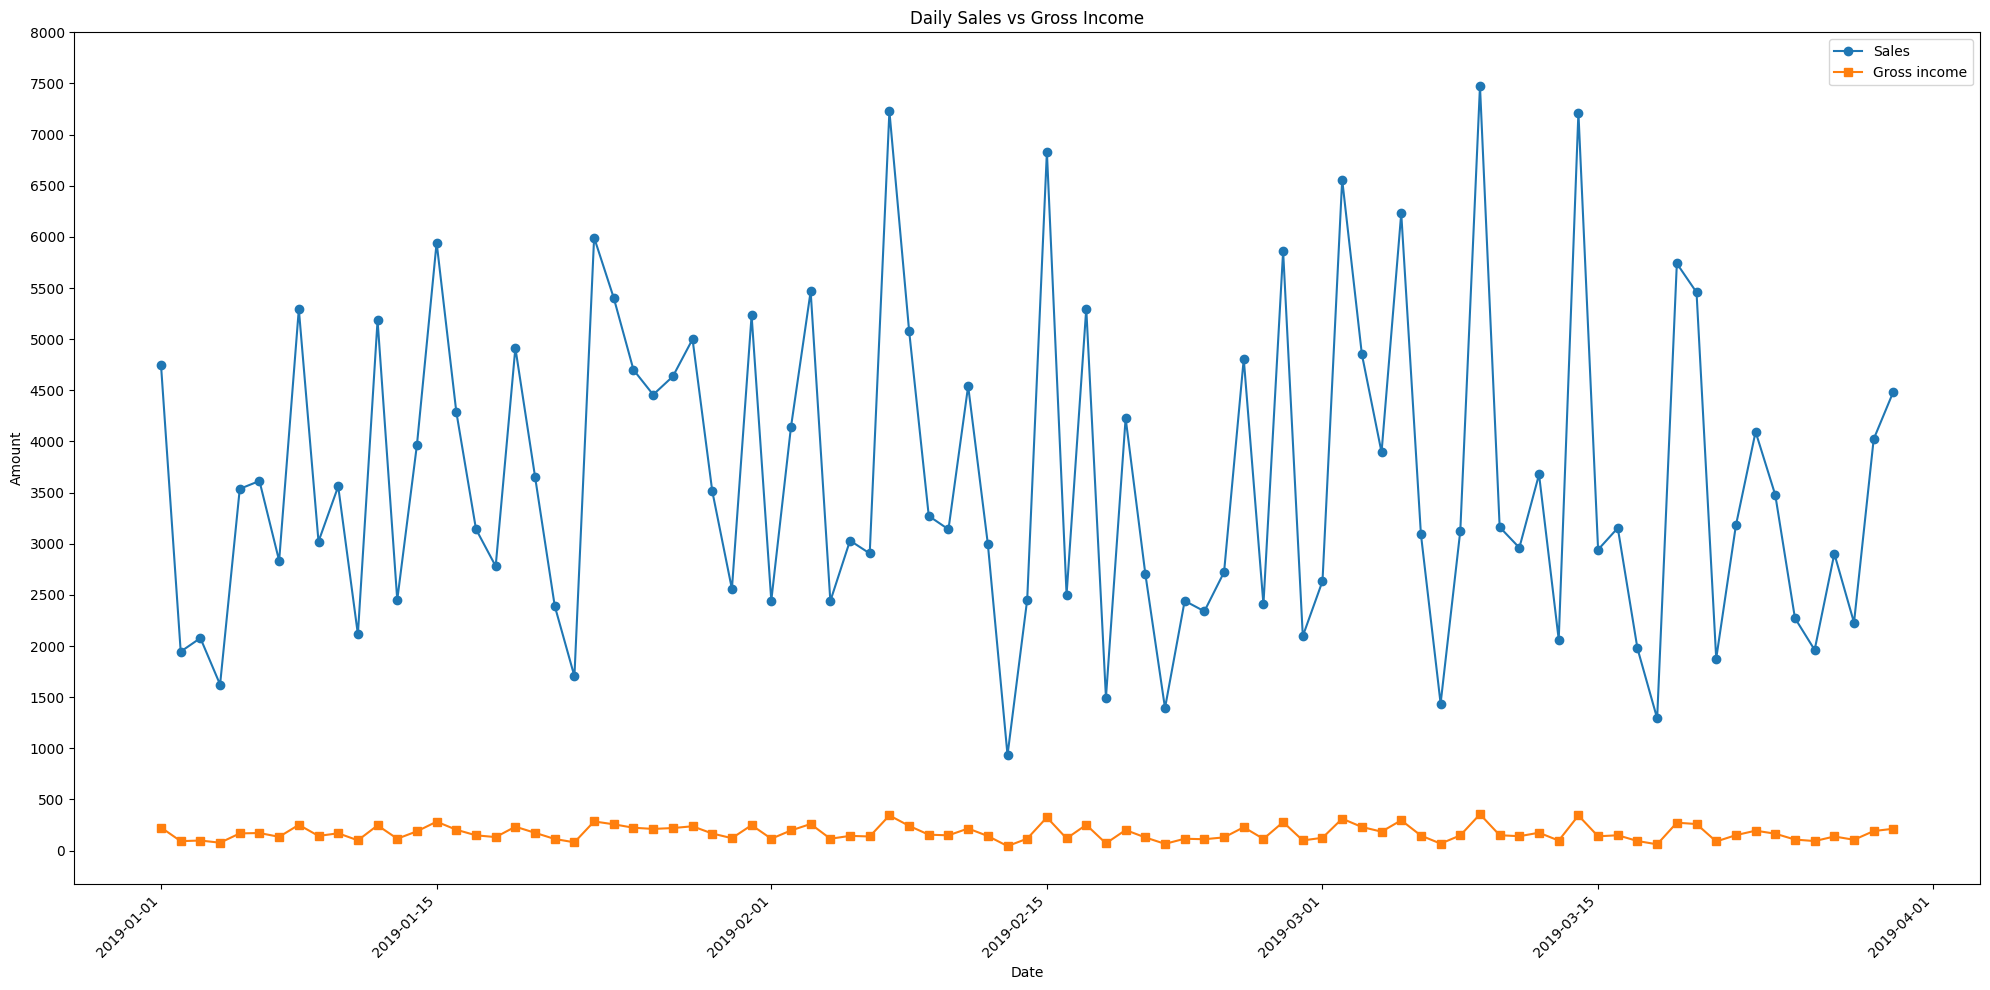

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Line plot ---
plt.figure(figsize=(20, 10))

plt.plot(daily_summary['Date'], daily_summary['Sales'], label='Sales', marker='o')
plt.plot(daily_summary['Date'], daily_summary['gross income'], label='Gross income', marker='s')

plt.xlabel('Date')
plt.ylabel('Amount')
plt.title('Daily Sales vs Gross Income')
plt.xticks(rotation=45, ha='right')  # Rotate dates
plt.yticks(np.arange(0, daily_summary[['Sales','gross income']].values.max()+1000, 500))
plt.legend()
plt.tight_layout()
plt.show()

#

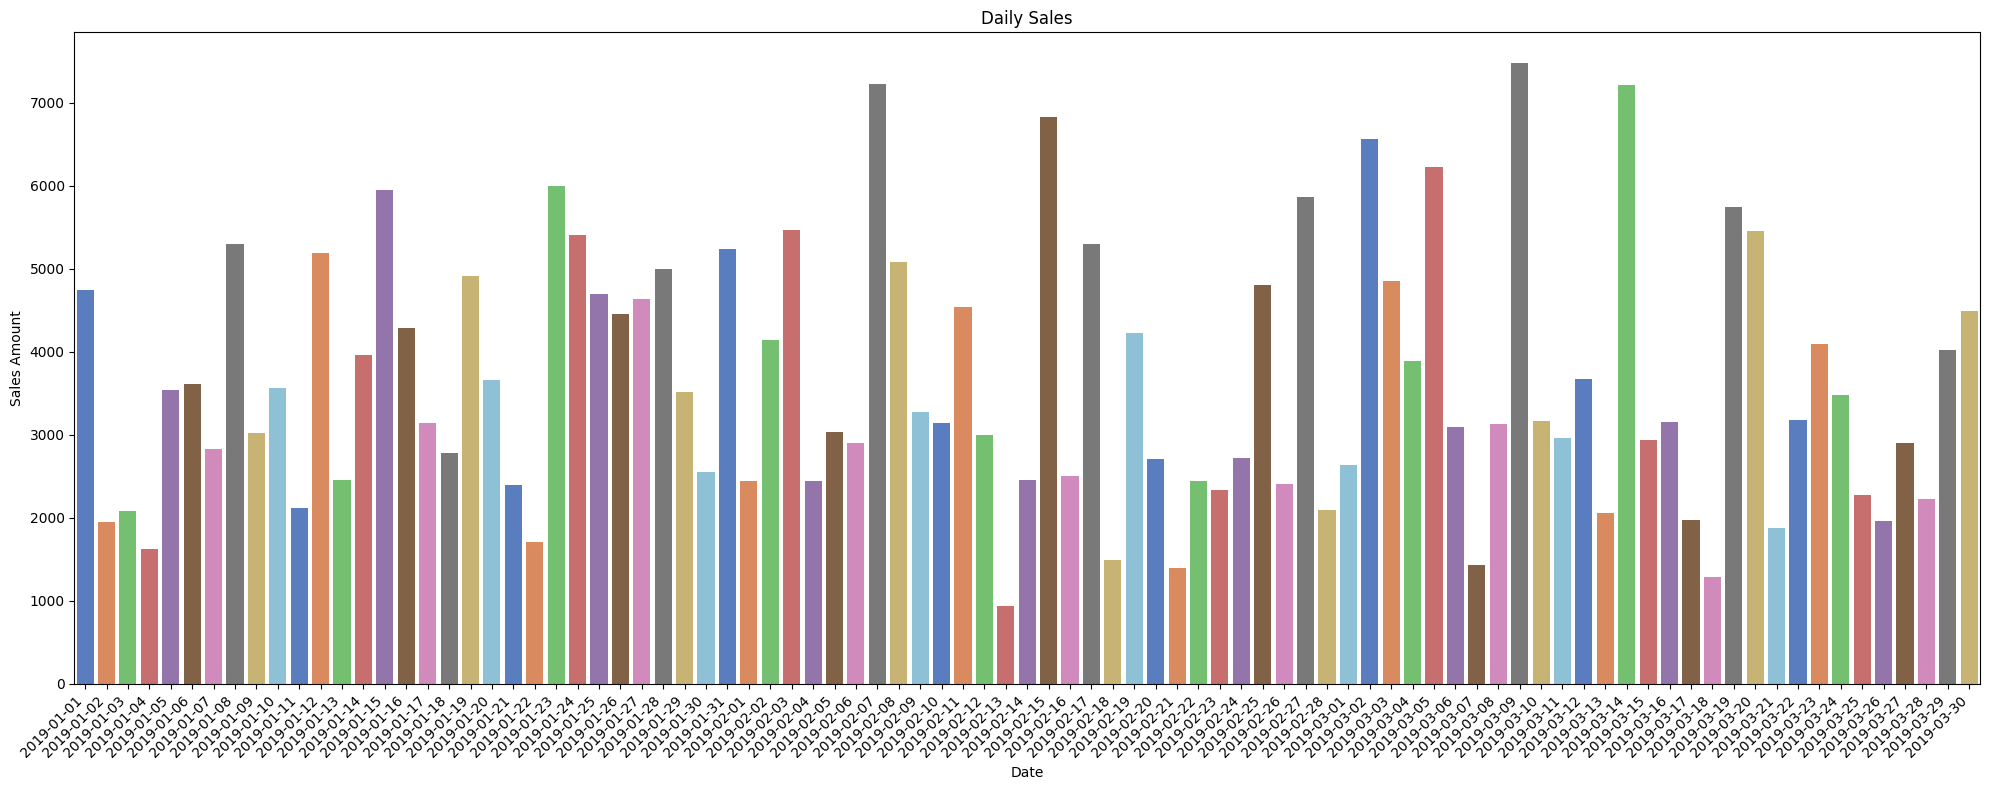

In [37]:
plt.figure(figsize=(20, 8))
sns.barplot(x='Date', y='Sales', data=daily_summary, palette='muted')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.title('Daily Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


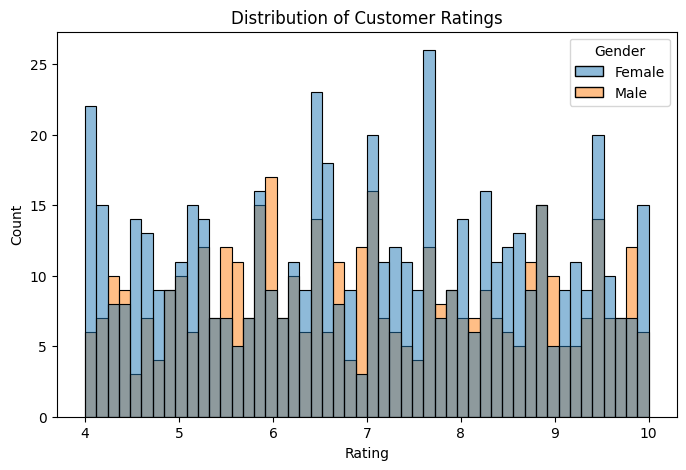

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Rating',hue='Gender', bins=50)
plt.title('Distribution of Customer Ratings')
plt.show()